# 3: rioxarray — Geospatial xarray

**Goal:** Open GeoTIFFs as **xarray** objects, then clip, align, and analyse them with the `.rio` accessor.



## What rioxarray adds

xarray is strong at labeled arrays (`time`, `y`, `x`) but does not know about CRS, geotransforms, or GeoTIFF I/O. **rioxarray** adds the `.rio` accessor:

- `open_rasterio(path)` — GeoTIFF/COG → `DataArray` with `band`, `y`, `x`
- `.rio.crs` / `.rio.bounds()` / `.rio.resolution()` — spatial metadata
- `.rio.clip_box()` / `.rio.clip()` / `.rio.reproject()` / `.rio.reproject_match()` — spatial ops
- `.rio.to_raster()` — write a GeoTIFF

Under the hood it uses **rasterio**. You keep xarray selection and math, and add GIS operations on the same object.





## Data folder

This notebook uses local rasters. Download the zip from [Google Drive](https://drive.google.com/file/d/10vINdbyeQtFCgrd7NhVawkC0v-wEGHwb/view?usp=sharing) and extract the `data/` folder next to this notebook (same directory as the other notebooks).

Precipitation and temperature are **ERA5-Land daily aggregates** (2024): one GeoTIFF each, **one band per day**. Elevation is a static **Copernicus DEM** at 30 m.

| File | Variable | Notes |
|------|----------|--------|
| `data/prec_daily_2024_ERA5LAND_native.tif` | Daily precipitation | metres; 366 bands  |
| `data/temp_daily_2024_ERA5LAND_native.tif` | Daily 2 m temperature | kelvin; 366 bands |
| `data/copernicus_dem_30m.tif` | Elevation | metres; single band |
| `data/NL_provinces.shp` | Province polygons | used later to clip to Utrecht |

Source: [ECMWF/ERA5_LAND/DAILY_AGGR](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR) and [Copernicus DEM](https://spacedata.copernicus.eu/collections/copernicus-digital-elevation-model). 



In [1]:
# Verify that the core libraries import correctly
import rioxarray as rxr
import numpy as np
from pathlib import Path

print("rioxarray:", rxr.__version__)



rioxarray: 0.19.0


In [2]:
prec_path = "data/prec_daily_2024_ERA5LAND_native.tif" #daily pcp for 2024, 365 bands
temp_path = "data/temp_daily_2024_ERA5LAND_native.tif" #daily temp for 2024, 365 bands
dem_path  = "data/copernicus_dem_30m.tif" #copernicus dem 30m, 1 band

SOURCE_DATASET = "ECMWF/ERA5_LAND/DAILY_AGGR"
SOURCE_URL = "https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR"

DEM_SOURCE = "Copernicus DEM 30m"
DEM_URL = "https://spacedata.copernicus.eu/collections/copernicus-digital-elevation-model"

## Inspect one raster

`open_rasterio` returns an xarray `DataArray`. Spatial metadata is on `.rio` — CRS, transform, bounds, resolution — without reading a separate world file.

In [3]:
prec = rxr.open_rasterio(prec_path, masked=True)

print("Loaded raster dims:", prec.dims)
print("Raster CRS:", prec.rio.crs)
print("Raster transform:", prec.rio.transform())
print("Raster bounds:", prec.rio.bounds())
print("Raster resolution:", prec.rio.resolution())

Loaded raster dims: ('band', 'y', 'x')
Raster CRS: EPSG:4326
Raster transform: | 0.01, 0.00, 3.36|
| 0.00,-0.01, 53.56|
| 0.00, 0.00, 1.00|
Raster bounds: (3.359031558682659, 50.74870631977094, 7.2307704332377964, 53.56043315906504)
Raster resolution: (0.008983152841195214, -0.008983152841195214)


## Open precipitation, temperature, and DEM

`masked=True` turns NoData pixels into NaN so they do not enter later means. Precipitation and temperature still have a `band` dimension (one step per day). The DEM is a single band.

In [4]:


# -----------------------------
# 1) Load precipitation raster
# -----------------------------
# open_rasterio() reads GeoTIFF and returns an xarray.DataArray
# masked=True automatically masks NoData values (so they don't affect calculations)
prec = rxr.open_rasterio(prec_path, masked=True)

# -----------------------------
# 2) Load temperature raster
# -----------------------------
temp = rxr.open_rasterio(temp_path, masked=True)

# -----------------------------
# 3) Load DEM raster (elevation)
# -----------------------------
dem = rxr.open_rasterio(dem_path, masked=True)

# Print basic info (dims, shape, metadata)
print("Precipitation raster:")
print(prec)

print("\nTemperature raster:")
print(temp)

print("\nDEM raster:")
print(dem)






Precipitation raster:
<xarray.DataArray (band: 366, y: 313, x: 431)> Size: 395MB
[49374498 values with dtype=float64]
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
  * x            (x) float64 3kB 3.364 3.373 3.381 3.39 ... 7.208 7.217 7.226
  * y            (y) float64 3kB 53.56 53.55 53.54 53.53 ... 50.77 50.76 50.75
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('20240101_2024-01-01', '20240102_2024-01-02', '20240103_...

Temperature raster:
<xarray.DataArray (band: 366, y: 313, x: 431)> Size: 395MB
[49374498 values with dtype=float64]
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
  * x            (x) float64 3kB 3.364 3.373 3.381 3.39 ... 7.208 7.217 7.226
  * y            (y) float64 3kB 53.56 53.55 53.54 53.53 ... 50.77 50.76 50.75
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    sc

In [5]:
# -----------------------------
# Print CRS information
# -----------------------------
print("PREC CRS:", prec.rio.crs)
print("TEMP CRS:", temp.rio.crs)
print("DEM  CRS:", dem.rio.crs)

# -----------------------------
# Print resolution (pixel size)
# -----------------------------
print("PREC resolution:", prec.rio.resolution())
print("TEMP resolution:", temp.rio.resolution())
print("DEM  resolution:", dem.rio.resolution())

# -----------------------------
# Print bounds (extent of raster)
# bounds = (minx, miny, maxx, maxy)
# -----------------------------
print("PREC bounds:", prec.rio.bounds())
print("TEMP bounds:", temp.rio.bounds())
print("DEM  bounds:", dem.rio.bounds())

PREC CRS: EPSG:4326
TEMP CRS: EPSG:4326
DEM  CRS: EPSG:4326
PREC resolution: (0.008983152841195214, -0.008983152841195214)
TEMP resolution: (0.008983152841195214, -0.008983152841195214)
DEM  resolution: (0.0004166666666666667, -0.000277777777777778)
PREC bounds: (3.359031558682659, 50.74870631977094, 7.2307704332377964, 53.56043315906504)
TEMP bounds: (3.359031558682659, 50.74870631977094, 7.2307704332377964, 53.56043315906504)
DEM  bounds: (3.308125, 50.75041666666666, 7.227291666666666, 53.57625)


In [6]:
print(prec.dims)

('band', 'y', 'x')


## Build one Dataset from rasters that do not match

The three files are not on the same grid. Precipitation and temperature share ERA5-Land’s coarse daily grid (~9 km). The DEM is 30 m, a different pixel size, and sometimes a different CRS. They also do not share a time axis: climate is **daily** (366 bands for 2024), elevation is **static**.

A single `Dataset` needs one spatial grid and a consistent time story:

- **Temporal.** Each climate GeoTIFF stores days as `band`. Map `band` → calendar dates and rename the dimension to `time`. The DEM stays 2-D (`y`, `x`). When it sits in the same Dataset as `prec`/`temp`, xarray **broadcasts** elevation across every date — no extra time copies.
- **Spatial.** `reproject_match` warps the DEM onto one ERA5 slice (`prec.isel(time=0)`). That copies the climate CRS, bounds, and resolution so every variable shares `y` and `x`.

After this cell, `ds` is one cube: daily `prec` and `temp` plus a DEM that lines up pixel-for-pixel. The next section can clip and write that cube as a whole.

In [7]:

import xarray as xr


def _to_time_da(path: str, name: str) -> xr.DataArray:
    """
    Read a multi-band GeoTIFF (daily bands) and map its 'band' dimension to a real 'time' coordinate.
    """
    da = rxr.open_rasterio(path, masked=True)

    # 2024 is a leap year -> 366 daily bands
    time = np.arange(np.datetime64("2024-01-01"), np.datetime64("2025-01-01"))

    if da.sizes.get("band") != time.size:
        raise ValueError(
            f"{Path(path).name}: expected {time.size} bands for 2024, got {da.sizes.get('band')}"
        )

    # Replace the 'band' coordinate with actual dates and rename 'band' -> 'time'
    da = da.assign_coords(band=time).rename(band="time")
    da.name = name
    return da

def _to_static_da(path: str, name: str, match_to: xr.DataArray) -> xr.DataArray:
    """
    Read a (typically single-band) static GeoTIFF (e.g., DEM), make it 2D (y, x),
    and reproject/resample it to match a reference grid (match_to).
    """
    da = rxr.open_rasterio(path, masked=True)

    # If it's stored with a 'band' dimension, drop it to get a 2D raster (y, x)
    if "band" in da.dims and da.sizes.get("band", 1) == 1:
        da = da.isel(band=0)

    # Ensure DEM grid matches ERA5 grid (same CRS, resolution, transform, shape)
    # ERA5-Land rasters (prec, temp) are already on the same grid + resolution (daily stacks).
    # But the Copernicus DEM (30m) has a much higher resolution, different pixel size, and sometimes even a different CRS.

    da = da.rio.reproject_match(match_to.isel(time=0))
    # reprojects the DEM and resamples it so it perfectly aligns with ERA5’s CRS, resolution, and grid, 
    # allowing all rasters to be combined and analyzed together inside one xarray Dataset.

    # match_to.isel(time=0) gives one 2D ERA5 raster (a template grid)
    # reproject_match() warps the DEM onto that exact template

    da.name = name
    return da

# --- Load time-varying rasters (time, y, x) ---
prec = _to_time_da(prec_path, "prec")
temp = _to_time_da(temp_path, "temp")

# --- Load static raster (y, x) and align to the ERA5 grid ---
dem = _to_static_da(dem_path, "dem", match_to=prec)

# --- Add variable metadata ---
prec.attrs.update({
    "long_name": "Daily total precipitation",
    "units": "m",
    "source_dataset": SOURCE_DATASET,
    "source_url": SOURCE_URL,
    "source_band": "total_precipitation_sum",
    "comment": "ERA5-Land daily aggregated total precipitation (units per dataset documentation).",
})

temp.attrs.update({
    "long_name": "Daily mean 2 m air temperature",
    "units": "K",
    "source_dataset": SOURCE_DATASET,
    "source_url": SOURCE_URL,
    "source_band": "temperature_2m_mean",
    "comment": "ERA5-Land daily aggregated 2 m temperature mean (units per dataset documentation).",
})

dem.attrs.update({
    "long_name": "Elevation above sea level",
    "units": "m",
    "source_dataset": DEM_SOURCE,
    "source_url": DEM_URL,
    "comment": "Static DEM aligned to the ERA5-Land grid for joint analysis.",
})

# --- Build a single Dataset containing both temporal + static spatial variables ---
ds = xr.Dataset({"prec": prec, "temp": temp, "dem": dem})

# Dataset-level metadata
ds.attrs.update({
    "title": "ERA5-Land daily aggregates for 2024 (precipitation, temperature) + Copernicus DEM",
    "source_dataset": SOURCE_DATASET,
    "source_url": SOURCE_URL,
    "temporal_coverage": "2024-01-01 to 2024-12-31",
    "time_resolution": "daily",
    "note": (
        "prec/temp: each GeoTIFF band corresponds to one day and was mapped to the time dimension. "
        "dem: static elevation (y,x) reprojected/resampled to match the ERA5 grid."
    ),
})

ds


<xarray.Dataset> Size: 791MB
Dimensions:      (x: 431, y: 313, time: 366)
Coordinates:
  * x            (x) float64 3kB 3.364 3.373 3.381 3.39 ... 7.208 7.217 7.226
  * y            (y) float64 3kB 53.56 53.55 53.54 53.53 ... 50.77 50.76 50.75
    spatial_ref  int64 8B 0
  * time         (time) datetime64[s] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
    band         int64 8B 1
Data variables:
    prec         (time, y, x) float64 395MB ...
    temp         (time, y, x) float64 395MB ...
    dem          (y, x) float32 540kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    title:              ERA5-Land daily aggregates for 2024 (precipitation, t...
    source_dataset:     ECMWF/ERA5_LAND/DAILY_AGGR
    source_url:         https://developers.google.com/earth-engine/datasets/c...
    temporal_coverage:  2024-01-01 to 2024-12-31
    time_resolution:    daily
    note:               prec/temp: each GeoTIFF band corresponds to one day a...

## Spatial operations

Tell rioxarray the spatial dimension names, then copy CRS onto the Dataset if it is only set on the variables. After this, `ds.rio.bounds()` and `.rio.clip_*` apply to the whole cube.

In [8]:
import rioxarray  # noqa: F401 (registers .rio accessor)

# Ensure rioxarray knows your spatial dimension names
ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)

# If CRS is missing at dataset-level but present on variables, you can write it once:
# (only do this if ds.rio.crs is None)
if ds.rio.crs is None and ds["prec"].rio.crs is not None:
    ds = ds.rio.write_crs(ds["prec"].rio.crs, inplace=False)

print("Dataset CRS:", ds.rio.crs)
print("Dataset bounds:", ds.rio.bounds())
print("Dataset resolution:", ds.rio.resolution())


Dataset CRS: EPSG:4326
Dataset bounds: (3.359031558682659, 50.74870631977094, 7.2307704332377964, 53.56043315906504)
Dataset resolution: (0.008983152841195214, -0.008983152841195214)


## Clip to a bounding box

`.rio.clip_box` keeps a rectangle (here a window in the northern Netherlands). Bounds are in the Dataset CRS — these coordinates are lon/lat.

In [9]:
import geopandas as gpd
from shapely.geometry import shape

# Bounds taken directly from your polygon coordinates
minx = 6.198312034306627
miny = 52.714539709668
maxx = 7.035449113615421
maxy = 53.17046416735059

# Clip the whole xarray Dataset ds using rioxarray
ds_clip = ds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

print(ds_clip)





<xarray.Dataset> Size: 29MB
Dimensions:      (x: 94, y: 52, time: 366)
Coordinates:
  * x            (x) float64 752B 6.202 6.211 6.22 6.229 ... 7.02 7.029 7.038
  * y            (y) float64 416B 53.17 53.16 53.15 53.14 ... 52.73 52.72 52.71
  * time         (time) datetime64[s] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    prec         (time, y, x) float64 14MB ...
    temp         (time, y, x) float64 14MB ...
    dem          (y, x) float32 20kB 3.492 4.004 7.659 ... 15.49 15.98 14.91
Attributes:
    title:              ERA5-Land daily aggregates for 2024 (precipitation, t...
    source_dataset:     ECMWF/ERA5_LAND/DAILY_AGGR
    source_url:         https://developers.google.com/earth-engine/datasets/c...
    temporal_coverage:  2024-01-01 to 2024-12-31
    time_resolution:    daily
    note:               prec/temp: each GeoTIFF band corresponds to one day a...


## Clip to a polygon

`.rio.clip` uses geometries. Load the Netherlands provinces shapefile, select **Utrecht**, reproject the polygon to the raster CRS, then clip. This is the same idea as clipping to any AOI polygon.

In [10]:
import geopandas as gpd

# 1) Read provinces shapefile
provinces = gpd.read_file("data/NL_provinces.shp")

# 2) Filter the province by attribute
utrecht = provinces[provinces["NAME_1"] == "Utrecht"].copy()


if utrecht.empty:
    raise ValueError("Could not find province with NAME_1 == 'Utrecth' (or 'Utrecht') in NL_provinces.shp")

# 3) Reproject province polygon to ds CRS
utrecht = utrecht.to_crs(ds.rio.crs)

# 4) Clip the whole Dataset to Utrecht boundary
ds_utrecht = ds.rio.clip(utrecht.geometry, utrecht.crs, drop=True, all_touched=False)

print(ds_utrecht)


<xarray.Dataset> Size: 22MB
Dimensions:      (x: 92, y: 41, time: 366)
Coordinates:
  * x            (x) float64 736B 4.81 4.819 4.828 4.837 ... 5.609 5.618 5.627
  * y            (y) float64 328B 52.3 52.29 52.28 52.27 ... 51.96 51.95 51.94
  * time         (time) datetime64[s] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    prec         (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    temp         (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    dem          (y, x) float32 15kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    title:              ERA5-Land daily aggregates for 2024 (precipitation, t...
    source_dataset:     ECMWF/ERA5_LAND/DAILY_AGGR
    source_url:         https://developers.google.com/earth-engine/datasets/c...
    temporal_coverage:  2024-01-01 to 2024-12-31
    time_resolution:    daily
    note:               prec/temp: each GeoTIFF band corresponds

## Derived layers

ERA5-Land temperature is **kelvin** — subtract 273.15 for °C. Precipitation is **metres** — 1 mm is `0.001`.

In [11]:
# Example A: Convert temperature from Kelvin to Celsius
temp_c = ds_utrecht["temp"] - 273.15
temp_c.name = "temp_c"
temp_c.attrs.update({"long_name": "Daily mean 2 m air temperature", "units": "°C"})

# Example B: Compute a simple "wet day" mask (precip > 1 mm)
# ERA5 precip in your metadata is meters ("m"), so 1 mm = 0.001 m
wet_mask = ds_utrecht["prec"] > 0.001
wet_mask.name = "wet_mask"


temp_c, wet_mask

(<xarray.DataArray 'temp_c' (time: 366, y: 41, x: 92)> Size: 11MB
 array([[[          nan,           nan,           nan, ...,
                    nan,           nan,           nan],
         [          nan,           nan,           nan, ...,
                    nan,           nan,           nan],
         [          nan,           nan,           nan, ...,
                    nan,           nan,           nan],
         ...,
         [          nan,           nan,           nan, ...,
          -265.88911451, -265.88911451, -265.88911451],
         [          nan,           nan,           nan, ...,
          -265.72163404, -265.72163404,           nan],
         [          nan,           nan,           nan, ...,
                    nan,           nan,           nan]],
 
        [[          nan,           nan,           nan, ...,
                    nan,           nan,           nan],
         [          nan,           nan,           nan, ...,
                    nan,           nan,      

In [12]:
# Combine results back into the dataset
ds_proc = ds_utrecht.copy()
ds_proc["temp_c"] = temp_c
ds_proc["wet_mask"] = wet_mask

In [13]:
# Handling NoData values
print("prec nodata:", ds_utrecht["prec"].rio.nodata)
print("temp nodata:", ds_utrecht["temp"].rio.nodata)
print("dem  nodata:", ds_utrecht["dem"].rio.nodata)



prec nodata: None
temp nodata: None
dem  nodata: nan


## Spatial-mean table

One row per day: mean precipitation and temperature over the Utrecht clip.

In [14]:
import pandas as pd

# Spatial mean over AOI (Utrecht) per day
prec_daily_mean = ds_utrecht["prec"].mean(dim=("y", "x"), skipna=True)
temp_daily_mean = ds_utrecht["temp"].mean(dim=("y", "x"), skipna=True)

# Create a DataFrame (time + both variables)
df_daily = pd.DataFrame({
    "date": prec_daily_mean["time"].values,
    "prec_daily_mean": prec_daily_mean.values,
    "temp_daily_mean": temp_daily_mean.values
})

# Optional: set date as index
df_daily = df_daily.set_index("date")

df_daily.head(10)

,prec_daily_mean,temp_daily_mean
date,,
2024-01-01,2.826346,7.301920
2024-01-02,22.847329,10.241196
2024-01-03,7.015954,8.758202
2024-01-04,7.026995,7.180712
2024-01-05,8.165069,6.800701
2024-01-06,0.224735,3.475624
2024-01-07,0.214102,-0.041887
2024-01-08,0.154529,-1.938696
2024-01-09,0.001302,-3.555100


## Maps for one day

Precipitation, temperature, and the aligned DEM for 1 June 2024. `robust=True` stretches the color scale using percentiles so outliers do not wash out the map.

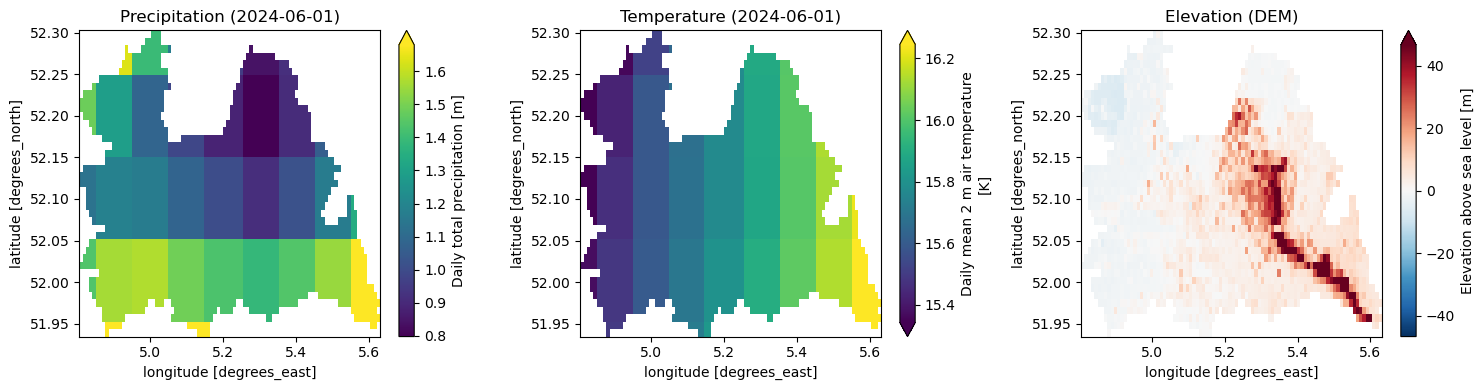

In [15]:
import matplotlib.pyplot as plt

day = "2024-06-01"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ds_utrecht["prec"].sel(time=day).plot(ax=axes[0], robust=True)
axes[0].set_title(f"Precipitation ({day})")

ds_utrecht["temp"].sel(time=day).plot(ax=axes[1], robust=True)
axes[1].set_title(f"Temperature ({day})")

ds_utrecht["dem"].plot(ax=axes[2], robust=True)
axes[2].set_title("Elevation (DEM)")

plt.tight_layout()
plt.show()


## Daily mean time series

Collapse space with `.mean(dim=("y", "x"))` to get one precipitation and one temperature value per day over Utrecht.

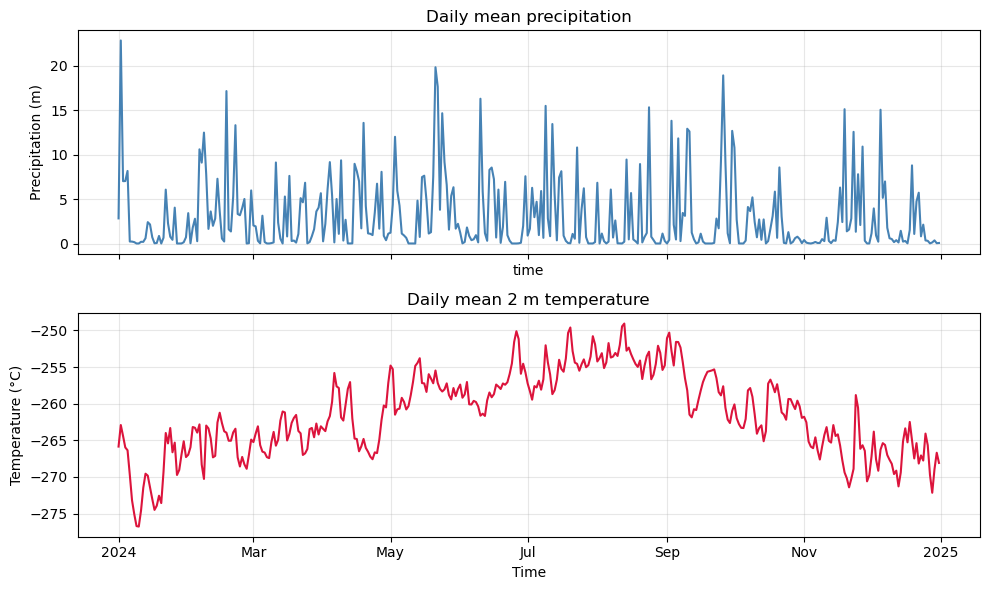

In [16]:
prec_mean_ts = ds_utrecht["prec"].mean(dim=("y", "x"), skipna=True)
temp_mean_ts = (ds_utrecht["temp"] - 273.15).mean(dim=("y", "x"), skipna=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

prec_mean_ts.plot(ax=axes[0], color="steelblue")
axes[0].set_title("Daily mean precipitation")
axes[0].set_ylabel("Precipitation (m)")
axes[0].grid(True, alpha=0.3)

temp_mean_ts.plot(ax=axes[1], color="crimson")
axes[1].set_title("Daily mean 2 m temperature")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Temperature (°C)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Write outputs

`.rio.to_raster()` writes a 2-D slice (DEM, or one day of precipitation). The full cube (time + DEM) goes to NetCDF. Create an `output/` folder next to the notebook if it does not exist.

In [17]:
#  Save data as GeoTIFF (raster outputs)

# Save DEM (2D y,x) to GeoTIFF
ds_utrecht["dem"].rio.to_raster("output/dem_aligned.tif")


# Save a single time slice as GeoTIFF (example: precipitation on a date)
day = "2024-06-01"

# Select one time slice -> becomes (y,x), then save
ds_utrecht["prec"].sel(time=day).rio.to_raster(f"output/prec_{day}.tif")


# Save the entire Dataset (time series + DEM) as NetCDF
ds_utrecht.to_netcdf("output/era5land_2024_prec_temp_dem.nc")


In [ ]:
# Example: save one raster layer with compression + dtype
out_path = "output/prec_day1_compressed.tif"

da = ds_utrecht["prec"].isel(time=0)   # (y, x) slice


da = da.rio.write_nodata(-9999)

da.rio.to_raster(
    out_path,
    nodata=-9999,
    dtype="float32",
    compress="lzw" # a popular lossless data compression algorithm that replaces repeating patterns of data with shorter numerical codes
)


## Precipitation on high, cold days

The DEM is (`y`, `x`) and temperature is (`time`, `y`, `x`). xarray broadcasts elevation across time. This cell uses the **full** `ds` (not the Utrecht clip) so the 50 m threshold has more terrain to work with.

Mean precipitation during cold days (below 0 °C) at high elevation (above 50 m)



Mean precipitation during cold days at high elevation: 2.9636384351787526 m


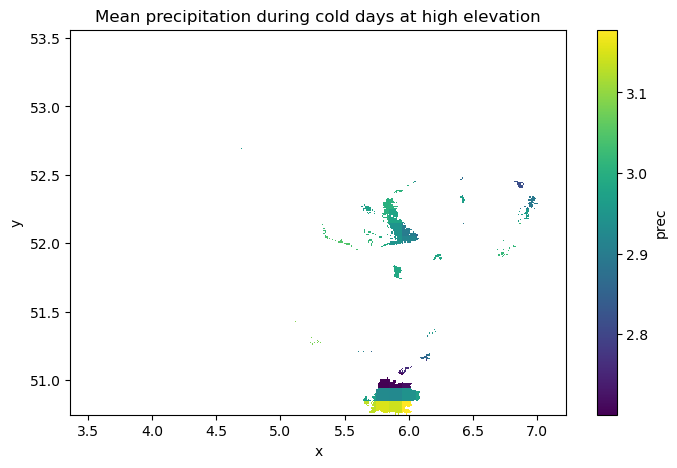

In [20]:
import matplotlib.pyplot as plt

# 1) Convert temperature from Kelvin to Celsius
temp_c = ds["temp"] - 273.15

# 2) Define high elevation mask (example threshold: > 50m)
high_elev = ds["dem"] > 50

# 3) Define cold day condition (below freezing)
cold_days = temp_c < 0

# 4) Precipitation only where (high elevation AND cold days)
#    DEM is (y,x) and temp is (time,y,x) -> xarray broadcasts DEM across time automatically
prec_cold_high = ds["prec"].where(high_elev & cold_days)

# 5) Compute mean precipitation map across time (result: y,x)
prec_cold_high_map = prec_cold_high.mean(dim="time", skipna=True)

# 6) Compute one final mean number (time + space)
mean_prec_cold_high = prec_cold_high.mean(dim=("time", "y", "x"), skipna=True)

print("Mean precipitation during cold days at high elevation:",
      float(mean_prec_cold_high.values), "m")

# 7) Plot the mean precipitation map
plt.figure(figsize=(8, 5))
prec_cold_high_map.plot(robust=True)
plt.title("Mean precipitation during cold days at high elevation")
plt.show()
